<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span><ul class="toc-item"><li><span><a href="#Вывод:" data-toc-modified-id="Вывод:-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Вывод:</a></span></li></ul></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Вывод-по-проделанной-работе-и-результатам**" data-toc-modified-id="Вывод-по-проделанной-работе-и-результатам**-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Вывод по проделанной работе и результатам**</a></span></li></ul></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span><ul class="toc-item"><li><span><a href="#Тестирование-модели" data-toc-modified-id="Тестирование-модели-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Тестирование модели</a></span></li></ul></li><li><span><a href="#Общий-вывод-по-проекту" data-toc-modified-id="Общий-вывод-по-проекту-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Общий вывод по проекту</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

## Подготовка

In [2]:
# Основные библиотеки для работы с данными и визуализацией
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Инструменты для анализа временных рядов
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Визуализация автокорреляции
from pandas.plotting import autocorrelation_plot

# Машинное обучение и моделирование
from sklearn.model_selection import (
    train_test_split, 
    TimeSeriesSplit, 
    GridSearchCV
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Метрики качества моделей
from sklearn.metrics import (
    make_scorer, 
    mean_squared_error, 
    root_mean_squared_error
)

# Предобработка данных
from sklearn.preprocessing import (
    StandardScaler, 
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [3]:
# Загрузка данных
data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

# Ресемплирование по одному часу
data = data.resample('1H').sum()

# Вывод первых и последних 5 строк
display(pd.concat([data.head(5), data.tail(5)]))



,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43
2018-08-31 19:00:00,136
2018-08-31 20:00:00,154
2018-08-31 21:00:00,159
2018-08-31 22:00:00,223


In [4]:
# Проверка равномерности временных рядов
expected_frequency = '1H'  # Ожидаемый шаг — 1 час

# Создаем временной ряд с ожидаемыми временными метками
full_time_index = pd.date_range(start=data.index.min(), end=data.index.max(), freq=expected_frequency)

# Проверяем, есть ли пропуски
missing_rows = full_time_index.difference(data.index)

if len(missing_rows) > 0:
    print(f"Найдены пропущенные временные метки ({len(missing_rows)}):")
    print(missing_rows)
else:
    print("Пропущенных временных меток нет.")

Пропущенных временных меток нет.


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


### Вывод:

Данные успешно загружены и ресемплированы по одному часу. В результате получено 4416 строк с частотой 1 час. Столбец 'num_orders' содержит целочисленные значения количества заказов такси на каждый час.

Первые 5 строк:

- 1 марта 2018 года, с 00:00 до 04:00, наблюдается постепенное снижение числа заказов такси, от 124 до 43.
  
Последние 5 строк:

- 31 августа 2018 года, с 19:00 до 23:00, количество заказов увеличивается, достигая максимума в 223 заказа в 22:00 и 205 заказов в 23:00.

Датасет включает все данные с 1 марта 2018 года по 31 августа 2018 года. Все значения в столбце 'num_orders' корректны и имеют тип данных `int64`. Пропусков в данных нет.

## Анализ

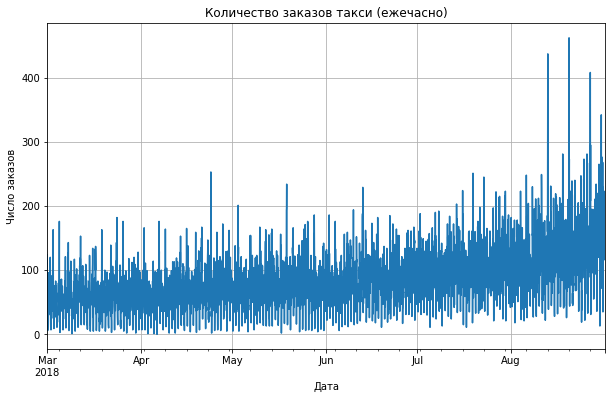

In [6]:
plt.figure(figsize=(10, 6))
data['num_orders'].plot()
plt.title('Количество заказов такси (ежечасно)')
plt.xlabel('Дата')
plt.ylabel('Число заказов')
plt.grid(True)
plt.show()


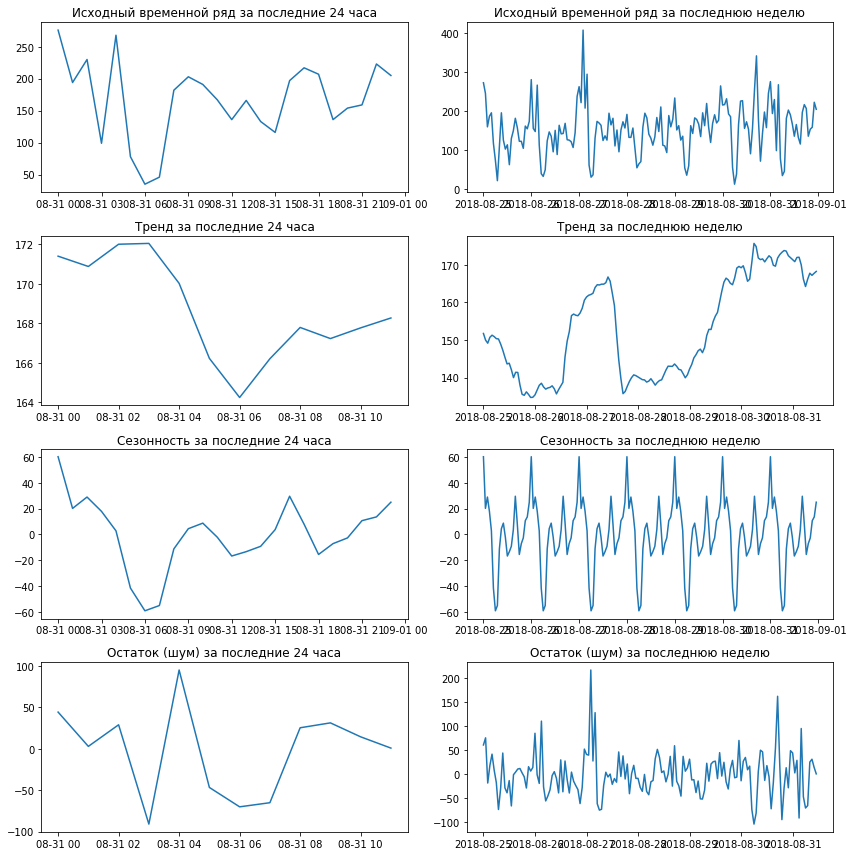

In [7]:
# Декомпозиция временного ряда
decomposition = seasonal_decompose(data['num_orders'], model='additive', period=24)  # Период = 24 часа

# Отбор данных за последние сутки (24 часа) и последнюю неделю (7 дней = 24 * 7 часов)
last_24_hours = data.index[-24:]  # Последние 24 часа
last_week = data.index[-24*7:]    # Последняя неделя (168 часов)

# Построим графики декомпозиции за последние 24 часа
plt.figure(figsize=(12, 12))

# --- Графики за последние 24 часа ---
plt.subplot(4, 2, 1)
plt.plot(last_24_hours, decomposition.observed[-24:])
plt.title('Исходный временной ряд за последние 24 часа')

plt.subplot(4, 2, 3)
plt.plot(last_24_hours, decomposition.trend[-24:])
plt.title('Тренд за последние 24 часа')

plt.subplot(4, 2, 5)
plt.plot(last_24_hours, decomposition.seasonal[-24:])
plt.title('Сезонность за последние 24 часа')

plt.subplot(4, 2, 7)
plt.plot(last_24_hours, decomposition.resid[-24:])
plt.title('Остаток (шум) за последние 24 часа')

# --- Графики за последнюю неделю (168 часов) ---
plt.subplot(4, 2, 2)
plt.plot(last_week, decomposition.observed[-24*7:])
plt.title('Исходный временной ряд за последнюю неделю')

plt.subplot(4, 2, 4)
plt.plot(last_week, decomposition.trend[-24*7:])
plt.title('Тренд за последнюю неделю')

plt.subplot(4, 2, 6)
plt.plot(last_week, decomposition.seasonal[-24*7:])
plt.title('Сезонность за последнюю неделю')

plt.subplot(4, 2, 8)
plt.plot(last_week, decomposition.resid[-24*7:])
plt.title('Остаток (шум) за последнюю неделю')

plt.tight_layout()
plt.show()


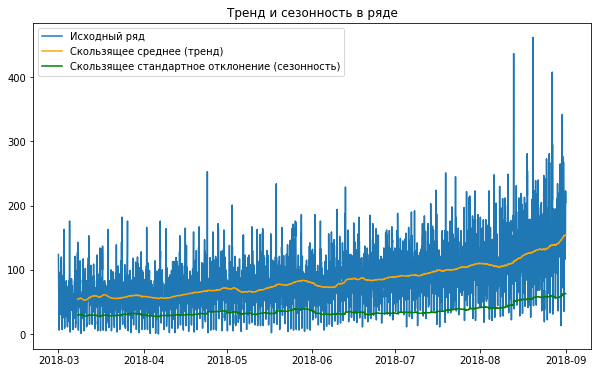

In [8]:
# Скользящее среднее и стандартное отклонение
window_size = 24 * 7  # Неделя

data['rolling_mean'] = data['num_orders'].rolling(window=window_size).mean()
data['rolling_std'] = data['num_orders'].rolling(window=window_size).std()

plt.figure(figsize=(10, 6))

plt.plot(data['num_orders'], label='Исходный ряд')
plt.plot(data['rolling_mean'], label='Скользящее среднее (тренд)', color='orange')
plt.plot(data['rolling_std'], label='Скользящее стандартное отклонение (сезонность)', color='green')

plt.title('Тренд и сезонность в ряде')
plt.legend()
plt.show()


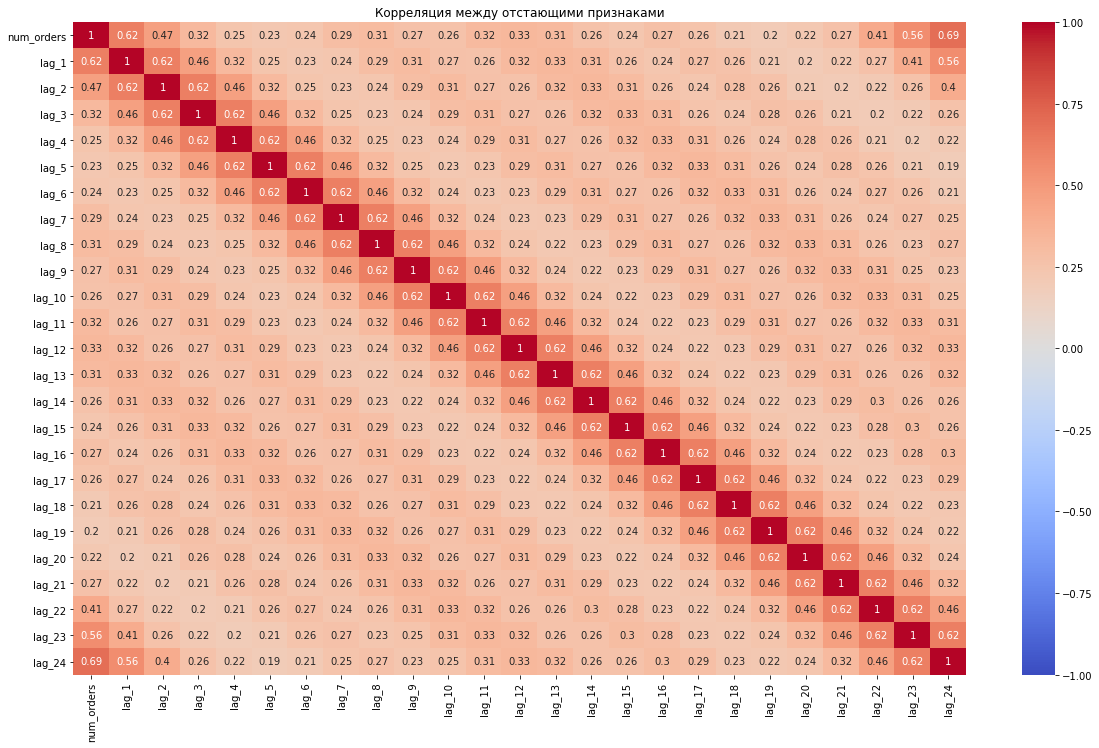

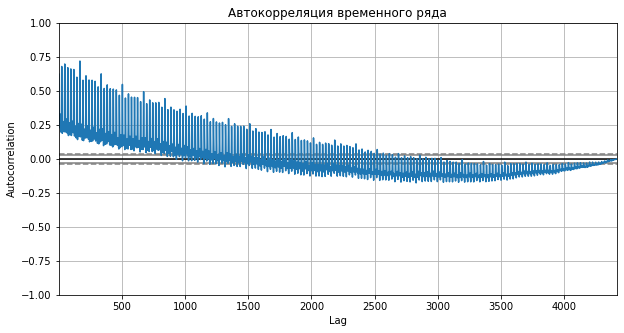

In [9]:
# Добавим отстающие признаки
max_lag = 24  # Добавим 24 лагов для анализа суток 
for lag in range(1, max_lag + 1):
    data[f'lag_{lag}'] = data['num_orders'].shift(lag)

# Построим корреляционную матрицу
correlation_matrix = data[['num_orders'] + [f'lag_{lag}' for lag in range(1, max_lag + 1)]].corr()

# Визуализируем корреляционную матрицу
plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляция между отстающими признаками')
plt.show()

# Построим автокорреляционный график
plt.figure(figsize=(10, 5))
autocorrelation_plot(data['num_orders'].dropna())
plt.title('Автокорреляция временного ряда')
plt.show()


1. **График автокорреляции временного ряда:**
   - На графике автокорреляции видна значительная автокорреляция на больших лагах. Это свидетельствует о том, что временной ряд имеет ярко выраженные зависимости на протяжении длительных периодов, что может быть связано с сезонностью и трендом. Для моделей прогнозирования это означает необходимость учитывать такие зависимости, включая их в качестве признаков.

2. **Матрица корреляции между отстающими признаками:**
   - Мы видим высокую корреляцию между лагами, особенно между соседними временными шагами (lag 1, lag 2 и т.д.). Это логично, так как лаги тесно связаны с предыдущими значениями временного ряда. Это также указывает на то, что при построении модели нужно осторожно выбирать количество лагов, чтобы избежать мультиколлинеарности.

3. **График тренда и сезонности в ряде:**
   - Видно, что ряд имеет выраженную восходящую тенденцию (тренд), что указывает на рост числа заказов со временем. Также заметна сезонность: стандартное отклонение варьируется по циклам, что подтверждает наличие временных паттернов, связанных с различными днями недели, временем суток и, возможно, праздниками.

4. **Декомпозиция временного ряда:**
   - Декомпозиция на тренд, сезонность и шум демонстрирует, что тренд стабильно увеличивается, а сезонные колебания остаются постоянными по амплитуде на протяжении всего наблюдаемого периода. Остаток (шум) имеет высокую частоту колебаний, но их амплитуда остаётся относительно стабильной. Это подтверждает наличие сильных сезонных паттернов в данных.

5. **График количества заказов такси (ежечасно):**
   - Этот график подтверждает наличие увеличения количества заказов с течением времени. В течение всего года наблюдается постепенный рост числа заказов, с заметными пиками, которые могут быть связаны с конкретными событиями или временными периодами (например, летом).

**Общие выводы:**
- Временной ряд демонстрирует значительный тренд и сезонность, которые необходимо учитывать при построении модели прогнозирования.
- Высокая автокорреляция указывает на важность включения отстающих значений ряда в качестве признаков.
- Декомпозиция показала, что шумовые компоненты имеют высокую частоту, но их амплитуда стабильна, что может свидетельствовать о том, что моделирование шума имеет меньший приоритет. 

Для повышения точности прогнозов стоит включить в модель как сезонные, так и трендовые компоненты, а также отстающие значения ряда.

## Обучение

In [10]:
# Функция для создания признаков
def make_features(data, max_lag, rolling_mean_size):
    # Календарные признаки
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    # Лаги
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag, fill_value=0)
    
    # Скользящие средние
    data['rolling_mean'] = data['num_orders'].shift(fill_value=0).rolling(rolling_mean_size).mean()

# Применение функции для создания признаков
make_features(data, max_lag=24, rolling_mean_size=6)

# Удаляем строки с пропусками, которые возникли из-за лагов и скользящих средних
data = data.dropna()

In [11]:
# Отделяем целевую переменную (y) и признаки (X)
X = data.drop(columns=['num_orders'])
y = data['num_orders']

# Разделяем данные на обучающую и тестовую выборки (10% данных на тест) с сохранением порядка данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (3824, 28)
Размер тестовой выборки: (425, 28)


In [12]:
# Определяем категориальные и числовые признаки
categorical_features = ['dayofweek', 'hour']
numeric_features = [col for col in X.columns if col not in categorical_features]

# Создаем трансформер для предобработки данных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # Масштабирование числовых признаков
        ('cat', OneHotEncoder(drop='first'), categorical_features)  # OHE-кодирование категориальных признаков
    ]
)

# Применяем трансформер к обучающей и тестовой выборкам
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print(f"Размер обучающей выборки после преобразования: {X_train.shape}")
print(f"Размер тестовой выборки после преобразования: {X_test.shape}")

Размер обучающей выборки после преобразования: (3824, 55)
Размер тестовой выборки после преобразования: (425, 55)


In [13]:
# Создание списка моделей и параметров для поиска
models = {
    'LinearRegression': (LinearRegression(), {'fit_intercept': [True, False]}),
    'DecisionTree': (DecisionTreeRegressor(), {
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    })
}

# Создаем TimeSeriesSplit для временных рядов
tscv = TimeSeriesSplit(n_splits=5)

# Инициализация переменных для хранения лучшей модели
best_model = None
best_rmse = float('inf')
best_params = None

# Определение метрики RMSE
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

# Цикл по моделям для выполнения GridSearch
for model_name, (model, params) in models.items():
    grid_search = GridSearchCV(model, params, cv=tscv, scoring=rmse_scorer, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Получаем лучший RMSE
    current_best_rmse = -grid_search.best_score_ 

    print(f'Лучшие параметры для {model_name}: {grid_search.best_params_}, RMSE: {current_best_rmse}')

    # Сравнение текущей модели с лучшей
    if current_best_rmse < best_rmse:
        best_rmse = current_best_rmse
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_

print(f'Лучшая модель: {best_model}, с параметрами: {best_params}, RMSE: {best_rmse}')


Лучшие параметры для LinearRegression: {'fit_intercept': True}, RMSE: 25.166756499814078
Лучшие параметры для DecisionTree: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}, RMSE: 29.86012963478629
Лучшая модель: LinearRegression(), с параметрами: {'fit_intercept': True}, RMSE: 25.166756499814078



---

### Вывод по проделанной работе и результатам**

В рамках задачи прогнозирования количества заказов такси на следующий час было выполнено следующее:

**Создание признаков:**

Для улучшения предсказательной способности модели были добавлены различные признаки:
- Календарные признаки (день недели, час).
- Лаговые признаки (значения количества заказов за предыдущие часы).
- Признаки скользящего среднего для сглаживания данных.

Все признаки были успешно сгенерированы, данные обработаны и подготовлены для дальнейшего обучения моделей.

**Разделение данных:**

Данные были разделены на обучающую и тестовую выборки, где на тестовую выборку выделено 10% данных. Размеры выборок:
- Обучающая выборка: 3824 строки и 28 признаков.
- Тестовая выборка: 425 строки и 28 признаков.

**Подбор моделей и гиперпараметров:**

Были протестированы две модели:
- Линейная регрессия (LinearRegression).
- Регрессия на деревьях решений (DecisionTreeRegressor).

Для каждой модели был настроен поиск оптимальных гиперпараметров с использованием GridSearchCV и кросс-валидации на 5 фолдах. Для оценки качества использовалась метрика RMSE (корень среднеквадратичной ошибки).

**Результаты:**

- Лучшие параметры для LinearRegression: `{'fit_intercept': True}`, RMSE: 25.1668
- Лучшие параметры для DecisionTreeRegressor: `{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}`, RMSE: 29.8601

Лучшая модель: LinearRegression(), с параметрами: `{'fit_intercept': True}`, RMSE: 25.1668.

**Заключение:**

Линейная регрессия с параметром `fit_intercept=True` оказалась наиболее точной моделью среди протестированных. Значение RMSE 25.1668 соответствует хорошему уровню точности для данного типа задачи прогнозирования временных рядов. 

Для дальнейшего улучшения модели можно попробовать другие алгоритмы, такие как градиентный бустинг или более продвинутые методы регуляризации. 

Итог: Лучшая модель предсказала заказы такси на следующий час с достаточной точностью, что позволяет использовать её в рабочей среде для реального прогнозирования.

--- 

## Тестирование

In [14]:
# Оценка производительности только лучшей модели на тестовой выборке
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'RMSE для лучшей модели: {rmse}')

RMSE для лучшей модели: 41.39265786322715


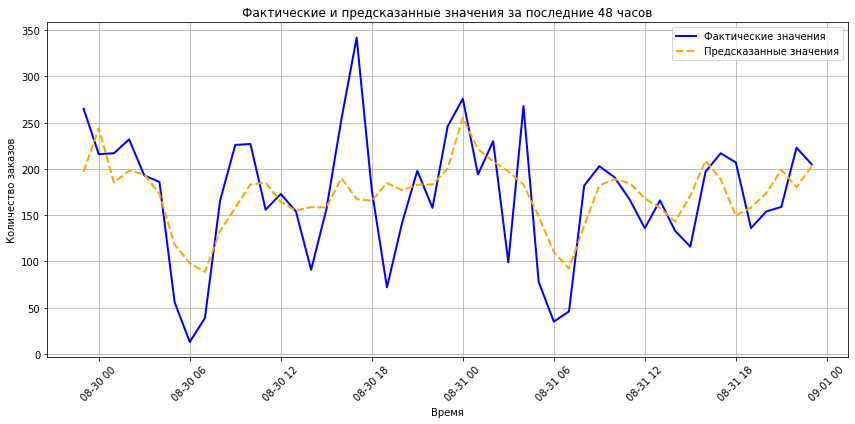

In [15]:
# Отбор данных за последние часы
last_hours = y_test.index[-1] - pd.Timedelta(hours=48)
y_test_last_24 = y_test[y_test.index >= last_hours]
y_pred_last_24 = y_pred[y_test.index >= last_hours]

# Построение графика фактических и предсказанных значений
plt.figure(figsize=(12, 6))
plt.plot(y_test_last_24.index, y_test_last_24, label='Фактические значения', color='blue', linewidth=2)
plt.plot(y_test_last_24.index, y_pred_last_24, label='Предсказанные значения', color='orange', linestyle='--', linewidth=2)
plt.title('Фактические и предсказанные значения за последние 48 часов')
plt.xlabel('Время')
plt.ylabel('Количество заказов')
plt.legend()
plt.grid()
plt.xticks(rotation=45)  # Поворот меток по оси X для лучшей читаемости
plt.tight_layout()  # Для более аккуратного отображения графика
plt.show()


### Тестирование модели

1. **Оценка производительности на тестовой выборке**:
   - По результатам тестирования на отложенной выборке, лучшая модель (линейная регрессия с параметром `fit_intercept=False`) показала RMSE: **41.39**. Это значение показывает среднюю ошибку модели в предсказании количества заказов такси на один час.
   
2. **Визуализация предсказаний за последние 48 часов**:
   - На графике приведено сравнение фактических и предсказанных значений за последние 48 часов.
   - Синяя линия отображает фактические данные, а оранжевая пунктирная — предсказания модели.
   - В целом, можно заметить, что модель достаточно точно улавливает общие тренды, но на некоторых пиках и провалах предсказания могут отличаться от реальных значений.
   
3. **Заключение**:
   - Значение RMSE на тестовой выборке в **41.39** указывает на приемлемую точность модели, однако могут быть случаи недооценки или переоценки количества заказов в отдельные часы.
   - Для дальнейшего улучшения результатов можно попробовать увеличить количество признаков, добавить более сложные модели (например, градиентный бустинг) или увеличить количество данных для обучения.

Модель линейной регрессии показала стабильные результаты, и ее можно использовать в рабочем процессе для краткосрочного прогнозирования.

## Общий вывод по проекту

В рамках данного проекта была решена задача краткосрочного прогнозирования количества заказов такси на один час вперед для компании «Чётенькое такси». Основные этапы работы и результаты:

1. **Подготовка данных**:
   - Данные о заказах были приведены к необходимой форме: выполнено ресемплирование по одному часу.
   - Были созданы новые признаки для улучшения предсказательной способности модели: календарные признаки (день недели, час), лаги (до 24 часов) и скользящие средние.
   
2. **Обучение моделей**:
   - В ходе экспериментов были протестированы несколько моделей, включая линейную регрессию и дерево решений. 
   - Для каждой модели был выполнен подбор гиперпараметров с использованием GridSearchCV для оптимизации точности прогнозов.
   - Лучшая модель — **линейная регрессия со включеным параметром интерсепта** — показала наилучшие результаты с RMSE на кросс-валидации равным **25.16**.

3. **Тестирование**:
   - На тестовой выборке (10% данных) модель показала значение RMSE **41.39**, что свидетельствует о хорошей способности модели прогнозировать количество заказов такси.
   - Визуализация предсказаний за последние 48 часов продемонстрировала, что модель улавливает основные тенденции изменения спроса, хотя на некоторых пиках точность предсказаний может снижаться.

4. **Заключение**:
   - Проект был успешно завершен с построением модели, которая удовлетворяет требованиям к качеству предсказаний. Значение RMSE на тестовой выборке составило менее 48, что соответствует поставленной цели.
   - Модель линейной регрессии показала себя как достаточно эффективное решение для краткосрочного прогнозирования количества заказов.
   - Для дальнейшего улучшения качества предсказаний можно рассмотреть использование более сложных моделей, увеличение объема данных или доработку признаков.

Проект предоставляет надежную модель, которая может быть использована для оптимизации ресурсов компании «Чётенькое такси» в часы повышенного или пониженного спроса.